In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.concat([pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_5/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_0/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_4/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_7/mpnn_design_stats_augmented_with_ntoc.csv")])

In [3]:
HEAVY_ATOMS = {
    "A": 5,   # Alanine
    "R": 11,  # Arginine
    "N": 8,   # Asparagine
    "D": 8,   # Aspartate
    "C": 6,   # Cysteine
    "Q": 9,   # Glutamine
    "E": 9,   # Glutamate
    "G": 4,   # Glycine
    "H": 10,  # Histidine
    "I": 8,   # Isoleucine
    "L": 8,   # Leucine
    "K": 9,   # Lysine
    "M": 8,   # Methionine
    "F": 11,  # Phenylalanine
    "P": 7,   # Proline
    "S": 6,   # Serine
    "T": 7,   # Threonine
    "W": 14,  # Tryptophan
    "Y": 12,  # Tyrosine
    "V": 7,   # Valine
}


def count_heavy_atoms(sequence: str) -> int:
    """
    Count the total number of heavy (non-hydrogen) atoms in a protein
    sequence, given as a string of one-letter amino acid codes
    (e.g. "AAAGAGYT"), plus one extra oxygen atom for the terminal
    -OH of the C-terminus (since HEAVY_ATOMS counts residues as they
    appear in a peptide chain, missing the terminal water's extra O).

    Unknown/invalid characters are skipped and a warning could be
    raised if strict checking is needed.
    """
    if not isinstance(sequence, str) or sequence == "" or sequence.lower() == "nan":
        return 0

    total = 0
    for aa in sequence.upper():
        total += HEAVY_ATOMS.get(aa, 0)

    # Add one oxygen for the free C-terminal carboxyl group (-OH),
    # since the residue masses/atom counts above assume internal
    # peptide-bonded residues (dehydrated). Remove this line if your
    # HEAVY_ATOMS values already account for termini.
    if total > 0:
        total += 1

    return total


def add_heavy_atom_column(df, col="proteina", new_col="n_heavy_atoms"):
    """
    Add a column to df with the heavy atom count for each sequence
    in `col`.
    """
    df[new_col] = df[col].apply(count_heavy_atoms)
    return df


[[ 1.         -0.78646177]
 [-0.78646177  1.        ]]


/tmp/ipykernel_475458/3364354068.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].apply(count_heavy_atoms)


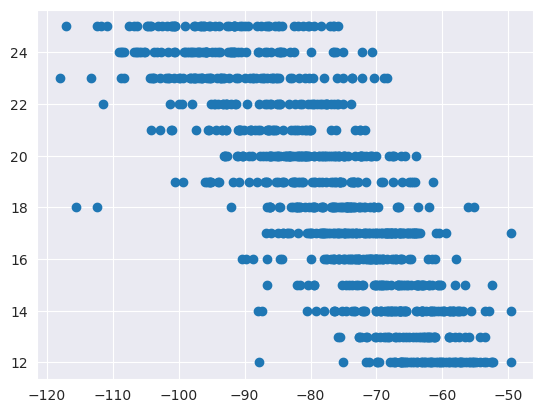

In [4]:
df = add_heavy_atom_column(df)
df = df.dropna(subset = "Y")
plt.scatter(df.Y, df.Length)
print(np.corrcoef(df.Y, df.Length))

/tmp/ipykernel_475458/1529410123.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_control.loc[:,"origin"] = "Control"
/tmp/ipykernel_475458/1529410123.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test.loc[:,"origin"] = "BALM guided"
/tmp/ipykernel_475458/1529410123.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

<Axes: xlabel='origin', ylabel='Average_dSASA'>

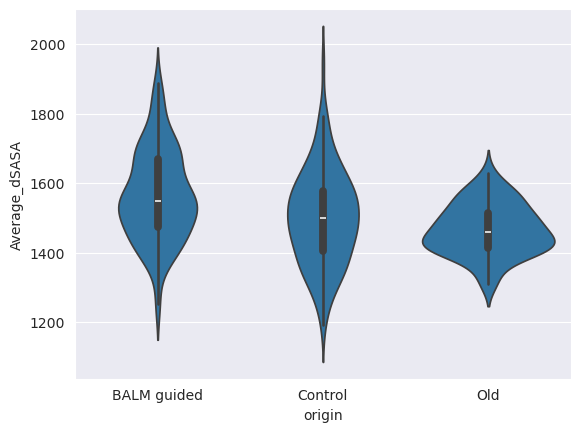

In [9]:
import seaborn as sns

df_15 = df.loc[df.Length == 15, ]

df_test = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_29_balm_deployed_weight_10_length_15/final_design_stats.csv")

df_control = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_31_control_length_15/final_design_stats.csv")
df_control.loc[:,"origin"] = "Control"
df_test.loc[:,"origin"] = "BALM guided"
df_15.loc[:,"origin"] = "Old"
df_plot = pd.concat([df_test, df_control, df_15])
sns.violinplot(df_plot, x= "origin", y= "Average_dSASA")


In [6]:
import statsmodels.formula.api as smf
print(smf.ols("Y ~ C(n_to_c) + Length ", data=df_all).fit().summary().tables[1])

NameError: name 'df_all' is not defined

(16, 233)

In [6]:
df_final = pd.concat([pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_5/final_design_stats.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_0/final_design_stats.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2/final_design_stats.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_4/final_design_stats.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_7/final_design_stats.csv")])

In [7]:
df_train = pd.read_csv("/FastHome/gyula/ppi_data/train_sets/PPI_protein_arranged_experimental.csv")
df_train = add_heavy_atom_column(df_train)

[[ 1.         -0.02386624]
 [-0.02386624  1.        ]]


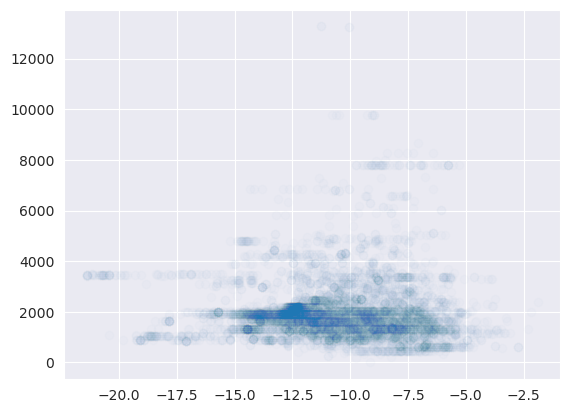

In [8]:
plt.scatter(df_train.Y, df_train.n_heavy_atoms, alpha = 0.01)
df_train = df_train.dropna(subset = "Y")
print(np.corrcoef(df_train.Y, df_train.n_heavy_atoms))

In [9]:
df.Length.value_counts()

Length
17    106
20     92
14     81
18     73
23     70
24     68
12     67
16     66
19     65
25     62
15     58
21     51
22     48
13     45
Name: count, dtype: int64

In [10]:
import scipy.stats
a = df.Average_dSASA
b = [1681.06, 1636.43, 1918.45 , 1772.27, 2030, 1959, 1613.65, 1923.34, 2152, 1292]
c = [1719.87, 1777.71, 1952.3, 1794.12,2008,1982, 1661, 1865]
scipy.stats.ttest_ind(a, b, axis=0, equal_var=True, nan_policy='propagate', alternative='less')

TtestResult(statistic=np.float64(-1.5758148157120586), pvalue=np.float64(0.057698974178829944), df=np.float64(960.0))

(array([1., 0., 0., 1., 4., 3., 1., 4., 3., 1.]),
 array([1292., 1378., 1464., 1550., 1636., 1722., 1808., 1894., 1980.,
        2066., 2152.]),
 <BarContainer object of 10 artists>)

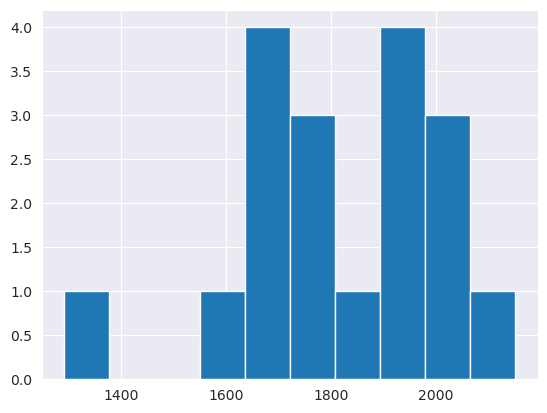

In [11]:
df_all = pd.concat([pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_5/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_0/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_4/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_7/mpnn_design_stats_augmented_with_ntoc.csv")])

<Axes: >

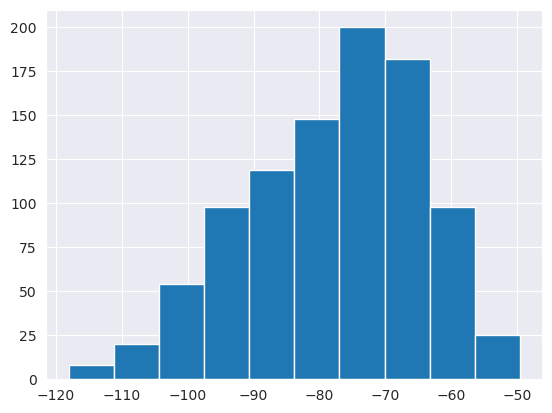

In [22]:
df_all.delta_total.hist()

In [13]:
df_control = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_24_control_interface_fixing/mpnn_design_stats_augmented_with_ntoc.csv")

In [17]:
df_all.iloc[:,-1].value_counts()

n_to_c
0.0    1372
1.0     855
Name: count, dtype: int64

(0.0, 8.0)

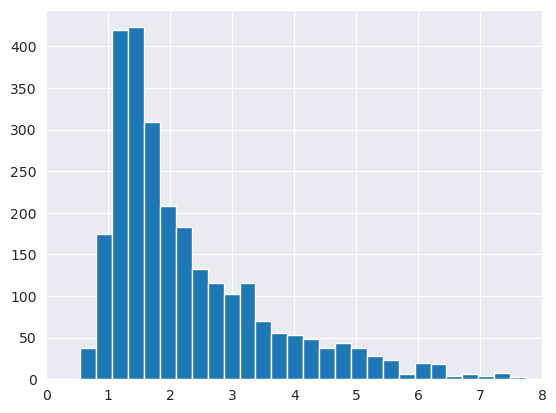

In [13]:
df_all.Average_Binder_RMSD.hist(bins = 30)
plt.xlim([0,8])

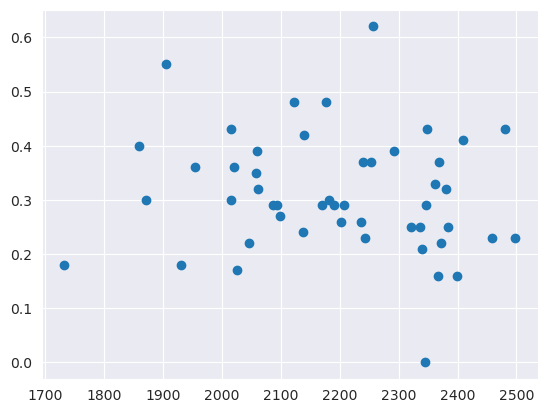

In [14]:
df_new = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_17_full_prot/final_design_stats.csv")
df_new_2 =  pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_18/final_design_stats.csv")

plt.scatter(df_new.Average_dSASA, df_new.MPNN_seq_recovery)

<Axes: >

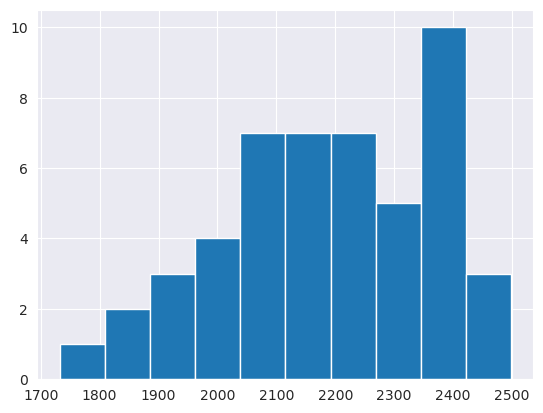

In [15]:
df_new.Average_dSASA.hist()

(1700.0, 2500.0)

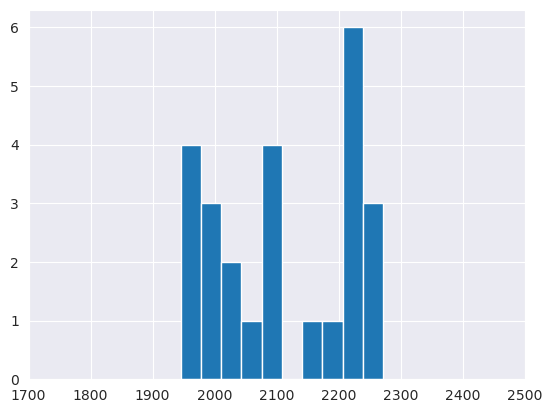

In [16]:
df_new_2.Average_dSASA.hist()
plt.xlim(1700, 2500)

In [17]:
df.Length.value_counts()

Length
17    106
20     92
14     81
18     73
23     70
24     68
12     67
16     66
19     65
25     62
15     58
21     51
22     48
13     45
Name: count, dtype: int64